**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset
from sklearn.datasets import load_iris
iris = load_iris()

df=pd.DataFrame(iris.data , columns=iris.feature_names)
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
df['target'].value_counts()

,count
target,
0,50
1,50
2,50


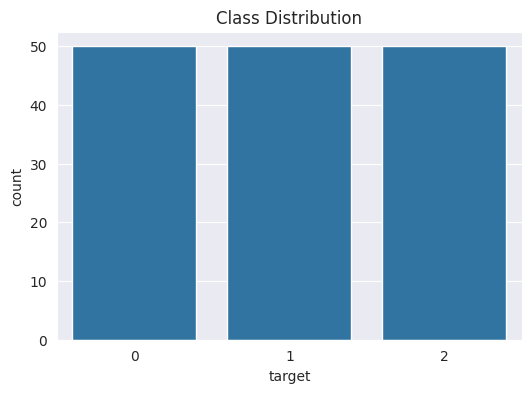

In [7]:
sns.set_style("darkgrid")
plt.figure(figsize=(6,4))
sns.countplot(x=df['target'])
plt.title("Class Distribution")
plt.show()

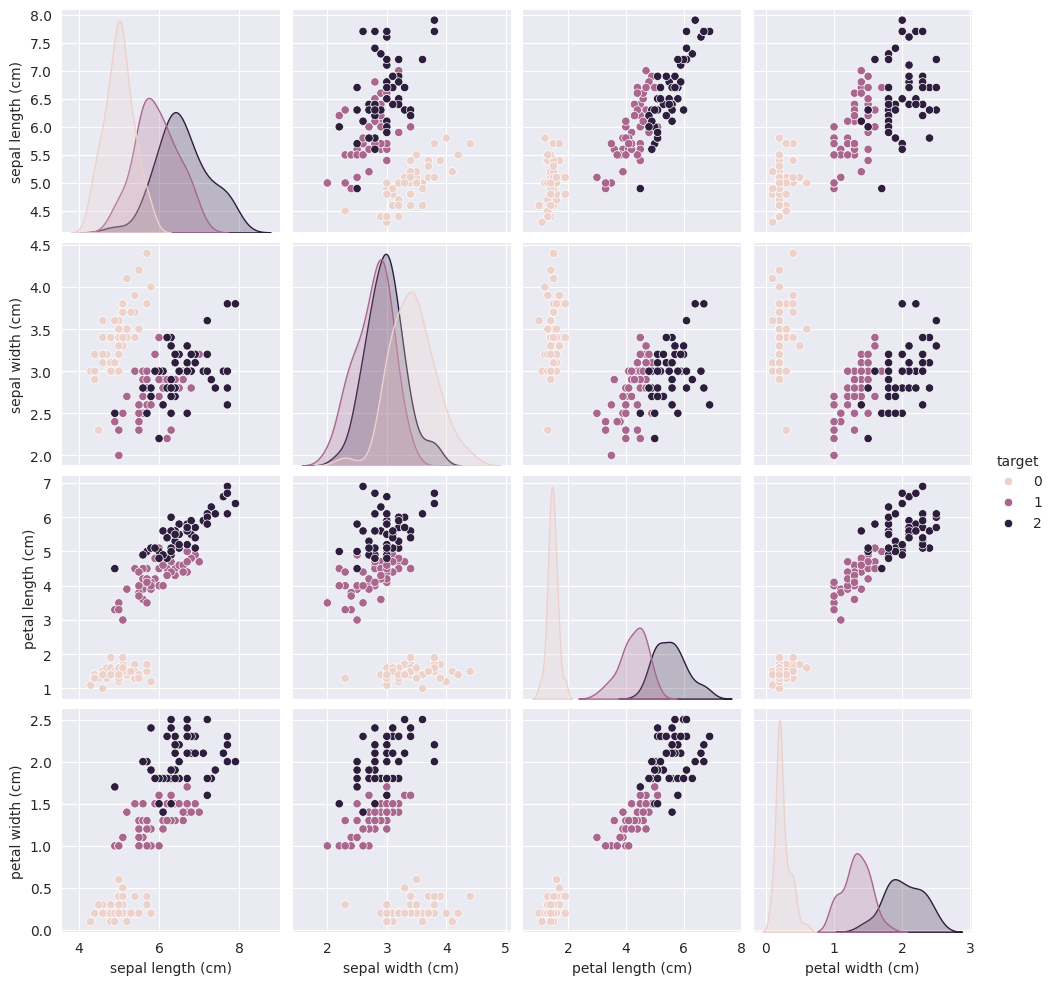

In [8]:
# pairplot
sns.pairplot(df , hue='target')
plt.show()

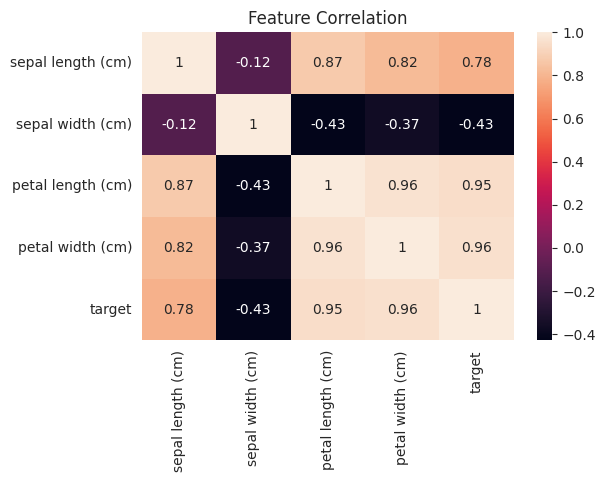

In [9]:
# correlation heatmap

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()


In [11]:
# Train Model on Iris

from sklearn.model_selection import train_test_split

X=df.drop('target',axis=1)
Y=df['target']

x_train,x_test,y_train,y_test= train_test_split(X,Y,test_size=0.2,random_state=42)

In [15]:
# Train 2 Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr= LogisticRegression()
rf = RandomForestClassifier()

lr.fit(x_train,y_train)
rf.fit(x_train,y_train)



RandomForestClassifier()

In [16]:
# comparee
print("Logistic :",lr.score(x_test,y_test))
print("Random Forest :", rf.score(x_test,y_test))

Logistic : 1.0
Random Forest : 1.0


In [17]:
import pandas as pd

importance = rf.feature_importances_

features = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(features)

             feature  importance
3   petal width (cm)    0.479020
2  petal length (cm)    0.412653
0  sepal length (cm)    0.078347
1   sepal width (cm)    0.029980


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [22]:
# Define parameters
param_grid ={
    'n_estimators':[50,100,150],
    'max_depth':[2,4,6,8]
}

In [23]:
# Apply GridSearch
rf=RandomForestClassifier()
grid= GridSearchCV(rf,param_grid,cv=5)
grid.fit(X,Y)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 4, 6, 8],
                         'n_estimators': [50, 100, 150]})

In [24]:
print("Best parameters:",grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'max_depth': 4, 'n_estimators': 100}
Best score: 0.9666666666666668


In [ ]:
import pickle

# Use best model (Random Forest in your case)
final_model = rf

pickle.dump(final_model, open("model.pkl", "wb"))